In [1]:
import pandas as pd
from data.loaders import load_single_target_tba, load_gsk_hepg2, load_pk, load_derbyshire_hepg2
from evaluate.train import generate_repeated_5xn_splits, prepare_mol_datasets, calc_metrics
from config import SplitType, TrainConfig
from data.preprocessing import preprocess_ray
import ray

In [2]:
df, df_classification_threshold = load_gsk_hepg2()
df = preprocess_ray(df)
ray.shutdown()

/home/rahul/delta/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:54: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
2026-03-13 15:43:27,090	INFO worker.py:1998 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
/home/rahul/delta/.venv/lib/python3.12/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
/home/rahul/delta/.venv/lib/python3.12/site-packages/ray/data/dataset.py:1560: UserWarning: Use 'expr' instead of 'fn' when possible for performant filters.
  warnings.warn(
2026-03-13 15:43:34,184	INFO logging.py:397 -- Registered dataset logger for dataset dataset_2_0
2026-03-13

In [3]:
train_config = TrainConfig(split_type=SplitType.SCAFFOLD)
splits = generate_repeated_5xn_splits(
    df,
    train_config.n_splits,
    train_config.split_type,
    random_state=train_config.random_seed,
)

_ = next(splits)
_, (train_df, val_df, test_df) = next(splits)

/home/rahul/delta/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:885: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/home/rahul/delta/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:885: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


In [4]:
from models import deltaprop
from models.config import DeltapropConfig

train_mol_ds, val_mol_ds, test_mol_ds, X_d_scaler = prepare_mol_datasets(
    train_df, val_df, test_df, deltaprop
)

model = deltaprop.train_func(
    config=DeltapropConfig(),
    train_mol_ds=train_mol_ds,
    val_mol_ds=val_mol_ds,
    X_d_scaler=X_d_scaler,
    binary_threshold=df_classification_threshold,
    batch_size=train_config.batch_size,
    max_epochs=train_config.max_epochs,
    early_stopping_patience=train_config.early_stopping_patience,
    random_seed=train_config.random_seed,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  227 K │ train │     0 │
│ 1 │ agg             │ NormAggregation    │      0 │ train │     0 │
│ 2 │ encoder         │ Encoder            │  180 K │ train │     0 │
│ 3 │ interaction     │ Interaction        │  270 K │ train │     0 │
│ 4 │ bn              │ Identity           │      0 │ train │     0 │
│ 5 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 6 │ ln              │ LayerNorm          │    600 │ train │     0 │
│ 7 │ loss_fn         │ BCEWithLogitsLoss  │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 679 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 679 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_loss improved. New best score: 0.403


...

Metric val_loss improved by 0.011 >= min_delta = 0.0. New best score: 0.311


Metric val_loss improved by 0.008 >= min_delta = 0.0. New best score: 0.303


Metric val_loss improved by 0.007 >= min_delta = 0.0. New best score: 0.296


Metric val_loss improved by 0.016 >= min_delta = 0.0. New best score: 0.280


Monitored metric val_loss did not improve in the last 20 records. Best score: 0.280. Signaling Trainer to stop.


In [5]:
clf_th = deltaprop.tune_binary_classification_threshold(
    model=model,
    train_mol_ds=train_mol_ds,
    train_labels=train_df["bin_target"].to_numpy(),
    val_mol_ds=val_mol_ds,
    val_labels=val_df["bin_target"],
    random_seed=train_config.random_seed,
    df_classification_threshold=df_classification_threshold,
)

In [6]:
clf_th

np.float64(0.5)

In [7]:
pred_probs, preds = deltaprop.predict_func(
    model=model,
    binary_classification_threshold=clf_th,
    train_mol_ds=train_mol_ds,
    train_labels=train_df["bin_target"].to_numpy(),
    test_mol_ds=test_mol_ds,
    df_classification_threshold=df_classification_threshold,
)

In [8]:
calc_metrics(pred_probs, preds, test_df["bin_target"])

{'accuracy': 0.8569620253164557,
 'balanced_accuracy': 0.7168957178247022,
 'f1': 0.4792626728110599,
 'precision': 0.4369747899159664,
 'recall': 0.5306122448979592,
 'mcc': 0.3997719492607309,
 'roc_auc': 0.8175356847941488,
 'average_precision': 0.42155533929592837}

In [9]:
train_embeds = deltaprop.embed_all(train_mol_ds, model)
val_embeds = deltaprop.embed_all(val_mol_ds, model)
test_embeds = deltaprop.embed_all(test_mol_ds, model, scale_X_d=True)

In [10]:
import torch

with torch.no_grad():
    pred_probs = (
        model.interaction(test_embeds, train_embeds)
        .sigmoid()
        .squeeze()
        .cpu()
        .numpy()
    )

In [11]:
(pred_probs < 0).sum()

np.int64(0)

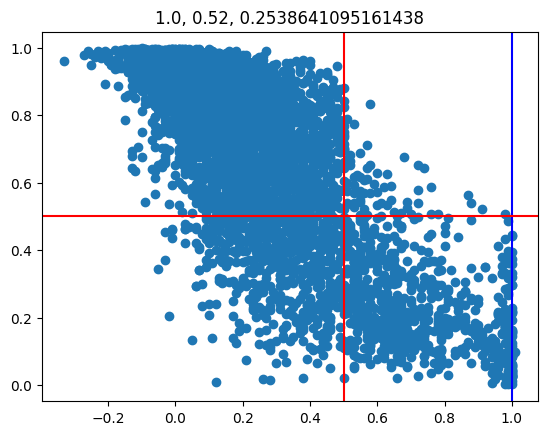

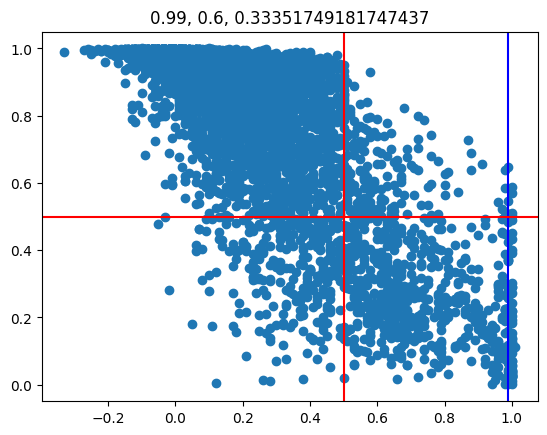

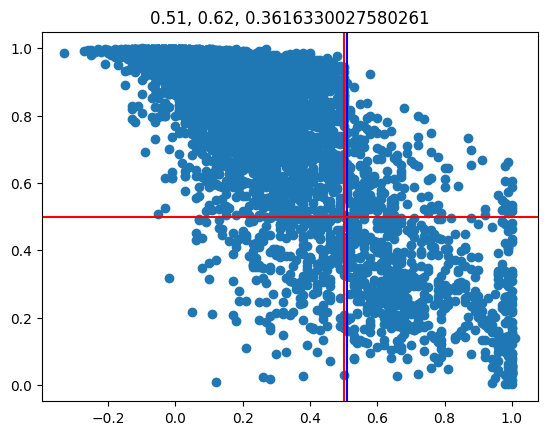

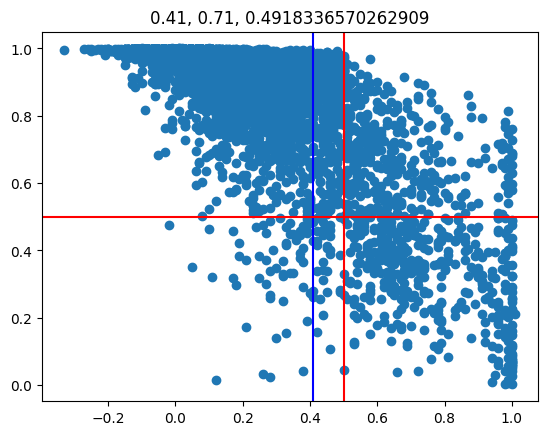

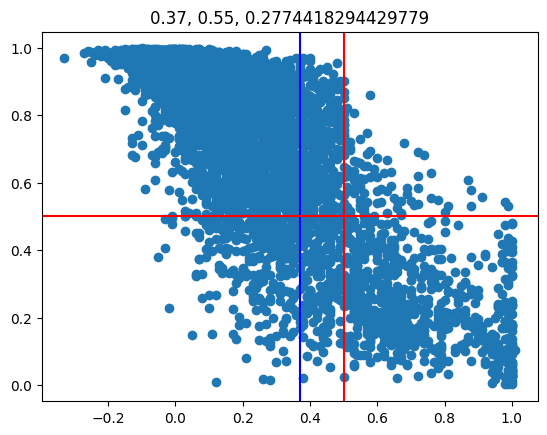

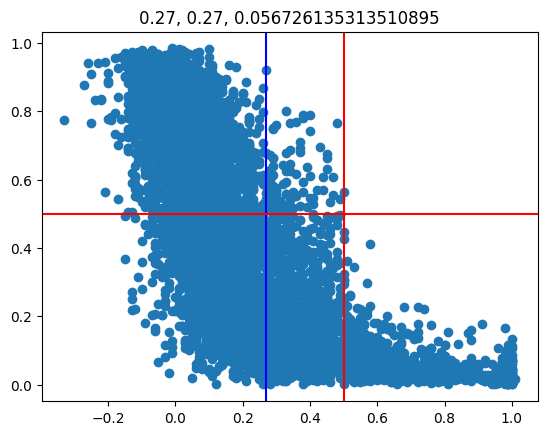

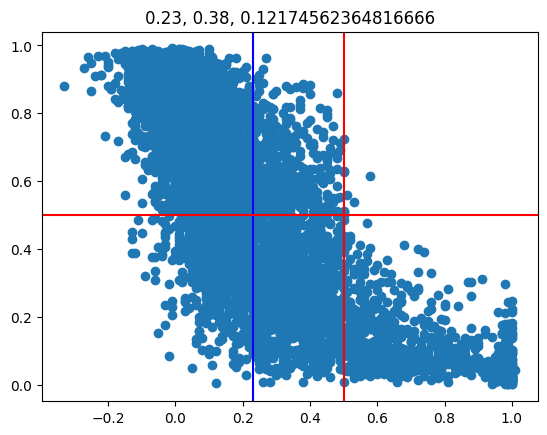

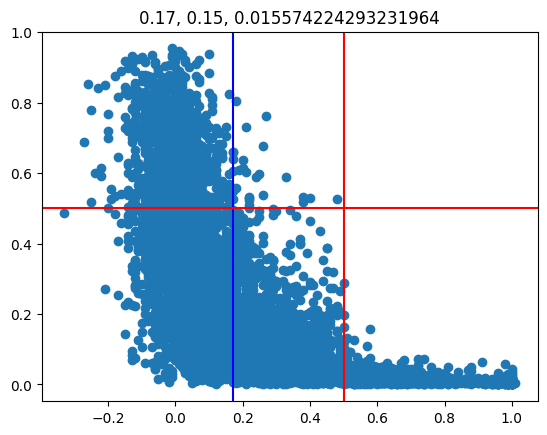

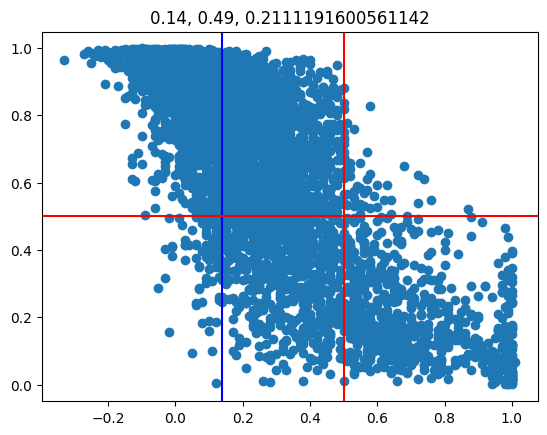

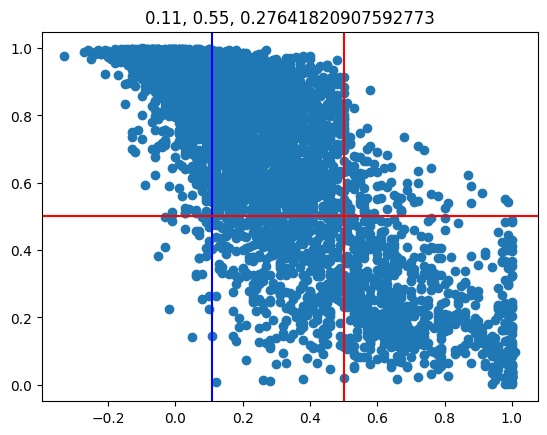

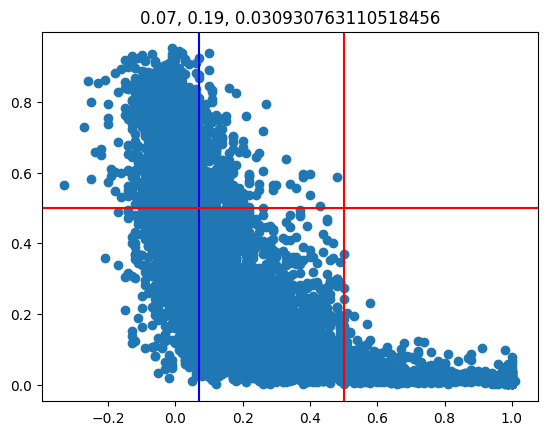

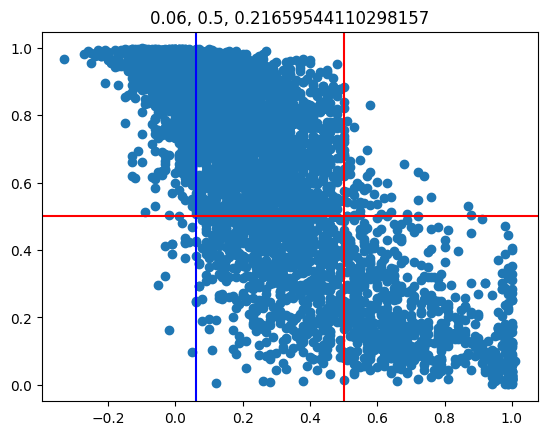

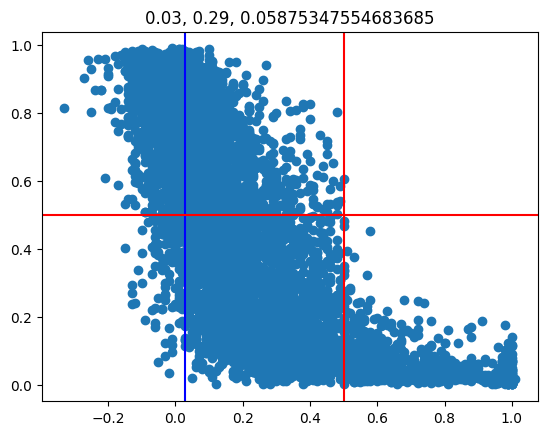

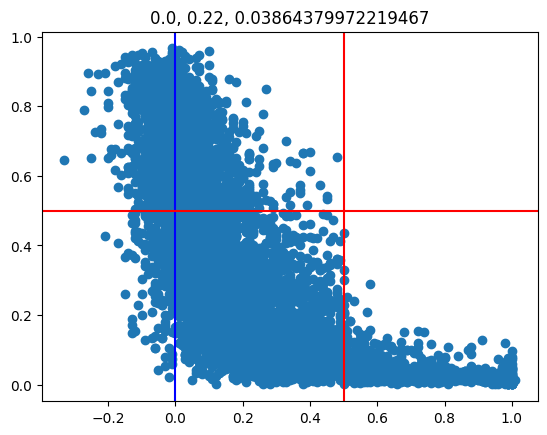

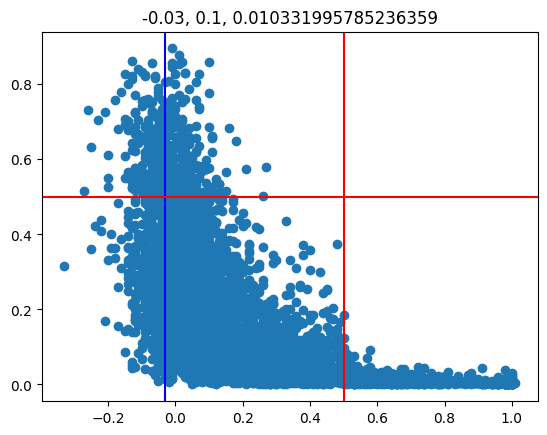

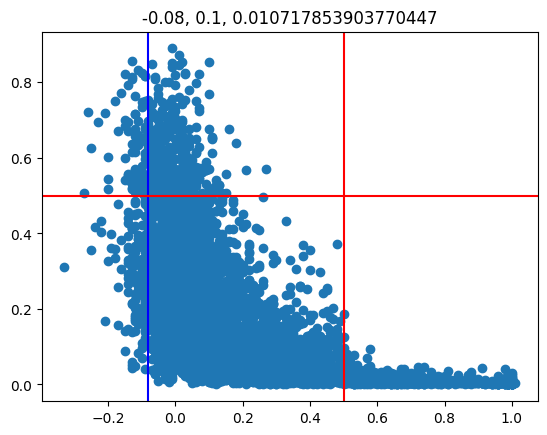

In [20]:
import matplotlib.pyplot as plt
import numpy as np

for z in range(0, pred_probs.shape[0], 50):

    

    pos_mask = train_df['cont_target'] > df_classification_threshold.th
    neg_mask = ~pos_mask
    pos_prob = pred_probs[z][pos_mask].mean()
    neg_prob = pred_probs[z][neg_mask].mean()
    alt_prob = round(float((pos_prob + neg_prob) / 2), 2)

    # if not (~test_df['bin_target'].iloc[z] and alt_prob > 0.5):
    #     continue

    Y = pred_probs[z]
    X = train_df['cont_target'].to_numpy()

    plt.scatter(X, Y)
    # for i, label in enumerate(sims[z][topk_train_cand_idxs]):
    #     plt.text(X[i], Y[i], round(label, 3), fontsize=12)
    
    plt.axvline(test_df['cont_target'].iloc[z], color="blue")
    plt.axvline(df_classification_threshold.th, color="red")
    plt.axhline(0.5, color="red")
    # plt.ylim(0, 1)

    # pos_mask = train_cand_df['cont_target'] > df_classification_threshold.th
    # neg_mask = ~pos_mask
    # pos_prob = np.nan_to_num(Y[pos_mask].mean())
    # neg_prob = np.nan_to_num(Y[neg_mask].mean())
    # prob = round(float((pos_prob + neg_prob) / 2), 2)

    # pos_mask = train_cand_df['cont_target'] > df_classification_threshold.th
    # neg_mask = ~pos_mask
    # pos_prob = (Y[pos_mask] * X[pos_mask]).mean()
    # neg_prob = (Y[neg_mask] * X[neg_mask]).mean()
    # alt_prob = round(float((pos_prob + neg_prob) / 2), 2)



    

    plt.title(f"{test_df['cont_target'].iloc[z]}, {alt_prob}, {pos_prob}")
    plt.show()
    # break

In [ ]:
# from sklearn.metrics import average_precision_score, roc_auc_score

# scores = []
# for idx in range(train_embeds.shape[0]):
#     scores.append(
#         roc_auc_score(test_df['bin_target'], pred_probs[:, idx])
#     )

# scores = np.array(scores)
# sorted_idxs = np.argsort(scores)[::-1]
# list(zip(train_df['cont_target'].iloc[sorted_idxs].astype(float), scores[sorted_idxs]))

In [ ]:
from rdkit import Chem
from rdkit.Chem import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import numpy as np


def tanimoto_similarity_matrix(
    mols_a: list,
    mols_b: list,
    radius: int = 2,
    n_bits: int = 2048,
) -> np.ndarray:
    """
    Calculate Tanimoto similarity between two lists of RDKit molecules.

    Args:
        mols_a: First list of RDKit Mol objects.
        mols_b: Second list of RDKit Mol objects.
        radius: Morgan fingerprint radius (default: 2).
        n_bits: Number of bits in the fingerprint (default: 2048).

    Returns:
        A (len(mols_a), len(mols_b)) numpy array of Tanimoto similarities.
    """
    generator = GetMorganGenerator(radius=radius, fpSize=n_bits)

    def to_fp(mol):
        if mol is None:
            raise ValueError("Invalid molecule (None) in input list.")
        return generator.GetFingerprint(mol)

    fps_a = [to_fp(m) for m in mols_a]
    fps_b = [to_fp(m) for m in mols_b]

    similarity_matrix = np.zeros((len(fps_a), len(fps_b)))

    for i, fp_a in enumerate(fps_a):
        similarity_matrix[i] = DataStructs.BulkTanimotoSimilarity(fp_a, fps_b)

    return similarity_matrix

In [ ]:
sims = tanimoto_similarity_matrix(test_mol_ds.mols, train_mol_ds.mols)
sims_topk = np.argsort(sims, axis=-1)[:, ::-1][:, :10]

sims_topk_mask = np.zeros_like(sims, dtype=np.bool)
np.put_along_axis(sims_topk_mask, sims_topk, True, axis=-1)

In [ ]:
import torch

with torch.no_grad():
    pred_probs = (
        model.interaction(test_embeds, train_embeds)
        .sigmoid()
        .squeeze()
        .cpu()
        .numpy()
    )

In [ ]:
df_classification_threshold

In [ ]:
pos_mask = train_df["bin_target"].to_numpy()
neg_mask = ~pos_mask

In [ ]:
# pos_contrib = pred_probs[:, sims_topk_mask]
# neg_contrib = pred_probs[:, sims_topk_mask]

np.where(pos_mask & sims_topk_mask, pred_probs, 0.0)

In [ ]:
pos_contrib_mask = pos_mask & sims_topk_mask
neg_contrib_mask = neg_mask & sims_topk_mask

In [ ]:
(pred_probs * pos_contrib_mask).sum(axis=-1) / (pos_contrib_mask.sum(axis=-1) + 1e-12)

In [ ]:
pos_contrib = (pred_probs * pos_contrib_mask).sum(axis=-1) / (pos_contrib_mask.sum(axis=-1) + 1e-12)
neg_contrib = (pred_probs * neg_contrib_mask).sum(axis=-1) / (neg_contrib_mask.sum(axis=-1) + 1e-12)

pos_prob = np.nan_to_num(pos_contrib)
neg_prob = np.nan_to_num(neg_contrib)
prob = (pos_prob + neg_prob) / 2

<Axes: >

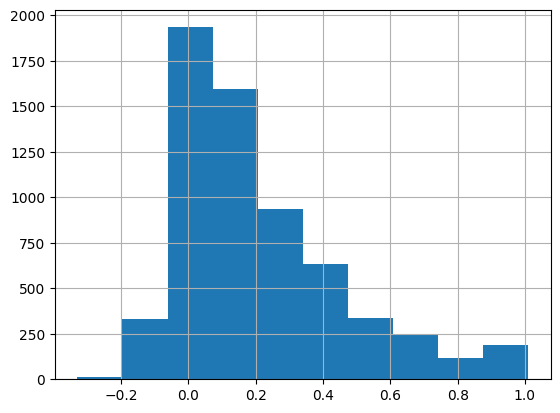

In [27]:
train_df['cont_target'].hist()